# Retieving data from WEkEO

In [1]:
import earthkit.data as ekd

#### Using the WEkEO grammar

In [2]:
d = ekd.from_source(
    "wekeo",
    "EO:EEA:DAT:CLMS_HRVPP_VPP",
    request={
        "dataset_id": "EO:EEA:DAT:CLMS_HRVPP_VPP",
        "productType": "TPROD",
        "productGroupId": "s1",
        "tileId": "32TQR",
        "resolution": "10",
        "startdate": "2023-01-01T00:00:00.000Z",
        "enddate": "2023-01-01T23:59:59.999Z",
        "bbox": [12.28091069558975, 45.40759897973081, 12.384715295944709, 45.45978517718846],
    },
)

To inspect the downloaded data we convert it into Xarray.

In [3]:
d.available_types

['xarray', 'pandas', 'fieldlist']

In [4]:
ds = d.to_xarray()
ds

<xarray.Dataset> Size: 482MB
Dimensions:      (x: 10980, y: 10980)
Coordinates:
  * x            (x) float64 88kB 7e+05 7e+05 7e+05 ... 8.097e+05 8.098e+05
  * y            (y) float64 88kB 5.1e+06 5.1e+06 5.1e+06 ... 4.99e+06 4.99e+06
    spatial_ref  int64 8B 0
Data variables:
    band_1       (y, x) float32 482MB ...
Attributes:
    TIFFTAG_COPYRIGHT:  Copernicus service information 2024
    file_creation:      2024:03:16 10:35:37
    input_time_window:  2018-10-01 to 2022-02-29
    TIIFTAG_SOFTWARE:   Timesat : TIMESAT4.1.8
    AREA_OR_POINT:      Area

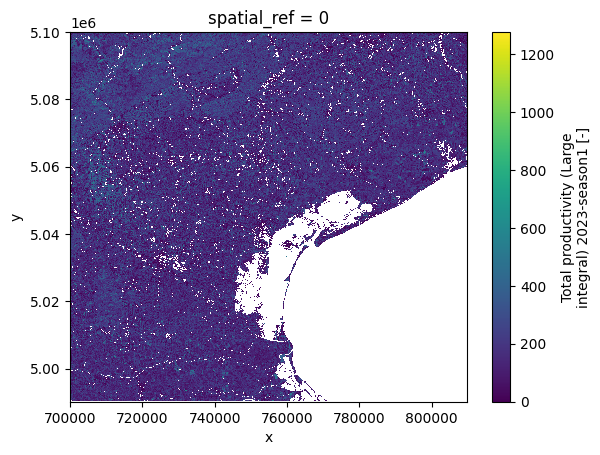

In [5]:
ds.band_1.plot()

####  Using the CDSAPI grammar

The following example retrieves ERA5 surface data in GRIB format:

In [6]:
import earthkit.data as ekd

d = ekd.from_source(
    "wekeocds",
    "EO:ECMWF:DAT:REANALYSIS_ERA5_SINGLE_LEVELS_MONTHLY_MEANS",
    request=dict(
        variable=["2m_temperature", "mean_sea_level_pressure"],
        product_type=["monthly_averaged_reanalysis_by_hour_of_day"],
        year="2012",
        month="12",
        time="12:00",
        data_format="grib",
        download_format="zip",
    ),
)

d.to_fieldlist().ls()

  0%|          | 0/1 [00:00<?, ?it/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2t,2012-12-01 12:00:00,2012-12-01 12:00:00,0 days,0,surface,0,regular_ll
1,msl,2012-12-01 12:00:00,2012-12-01 12:00:00,0 days,0,surface,0,regular_ll
